## RandomForest+CatBoost Models

In [28]:
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from catboost import CatBoostClassifier, Pool
import datetime as datetime
import datetime as dt

# Read the parquet file:
marketData = pd.read_parquet('MarketData_2022-2026.parquet')
# Create Time variable
marketData['Time'] = marketData['StartDateTime'].dt.time
marketData = marketData[marketData['StartDateTime'] >= '2023-04-01']

In [29]:
# Emily

dt = marketData["StartDateTime"].diff()
print(dt.value_counts().head())

dup_count_by_diff = (dt == pd.Timedelta(0)).sum()
non_30min_count = ((dt.notna()) & (dt != pd.Timedelta("30min"))).sum()
dup_mask_any = marketData["StartDateTime"].duplicated(keep=False)

num_dup_rows = dup_mask_any.sum()
num_unique_dup_timestamps = marketData.loc[dup_mask_any, "StartDateTime"].nunique()

print("Total rows involved in duplicate StartDateTime groups:", num_dup_rows)
print("Number of unique StartDateTime values that are duplicated", num_unique_dup_timestamps)

# Exact duplicate rows across all columns
exact_dup_row_mask = marketData.duplicated(keep='first')
print("\nExact duplicate ROWS (all columns identical):", exact_dup_row_mask.sum())

# drop exact duplicates
before = len(marketData)
data_drop_dup = marketData.drop_duplicates(keep='first').copy()
after = len(data_drop_dup)

print(f"Dropped {before - after} exact duplicate rows.")
# check if duplicates still remain
dup_mask_any_after = data_drop_dup["StartDateTime"].duplicated(keep=False)
remaining_dup_times = data_drop_dup.loc[dup_mask_any_after, "StartDateTime"].nunique()
remaining_dup_rows = dup_mask_any_after.sum()

if remaining_dup_times > 0:
    remaining_groups = data_drop_dup.loc[dup_mask_any_after].groupby("StartDateTime", sort=False)

    # identify what differs in the non-identical rows with same StartDateTime
    unique_rows_per_time_after = remaining_groups.apply(lambda g: g.drop_duplicates().shape[0])
    t_problem = unique_rows_per_time_after[unique_rows_per_time_after > 1].index[0]
    grp = data_drop_dup.loc[data_drop_dup["StartDateTime"] == t_problem].copy()

    print(f"\nExample timestamp with non-identical rows: {t_problem}")
    print("Group size:", len(grp))

    # Find columns that vary within the group
    nunique_cols = grp.nunique(dropna=False)
    varying_cols = nunique_cols[nunique_cols > 1].index.tolist()

    print("\nColumns that differ within timestamp group:")
    print(varying_cols)

    # Show just those columns + few identifiers to inspect
    id_cols = ["StartDateTime"]
    if "TradeDate" in grp.columns: id_cols.append("TradeDate")
    if "Time" in grp.columns: id_cols.append("Time")

    print("\nRows for this timestamp (only columns + identifiers):")
    print(grp[id_cols + varying_cols].head(10))

else:
    print("\nNo remaining duplicated StartDateTime values after dropping exact duplicates.","\nStartDateTime can be trated as unique index for modelling")

data = data_drop_dup

print("\n----- Checks ------")
print(data["StartDateTime"].is_monotonic_increasing)

dt2 = data["StartDateTime"].diff()
print("\nMost common StartDateTime differences after dropping exact duplicates:")
print(dt2.value_counts().head(10))

print("\n0-minute diffs remaining:", (dt2 == pd.Timedelta(0)).sum())
print("Non-30-min diffs remaining:", ((dt2.notna()) & (dt2 != pd.Timedelta('30min'))).sum())


nan_decision_table = pd.DataFrame({
    "nan_fraction": marketData.isna().mean(),
})

nan_decision_table["classification"] = np.where(
    nan_decision_table["nan_fraction"] > 0.9,
    "structual_or_unusable",
    np.where(nan_decision_table["nan_fraction"] > 0.1,
            "structural_market_schedule",
            "minor_or_random"
        )
)
print(nan_decision_table.sort_values("nan_fraction", ascending=False).head(20))
print("\n",nan_decision_table.sort_values("nan_fraction", ascending=False).tail(20))
cols_all_nan = nan_decision_table.index[
    nan_decision_table['nan_fraction'] == 1.0
].tolist()
print("Dropping columns with nan_fraction = 1.0:")
print(cols_all_nan)

marketData = marketData.drop(columns = cols_all_nan)
print("New dataset shape:", marketData.shape)

StartDateTime
0 days 00:30:00    48285
0 days 00:00:00     2859
Name: count, dtype: int64
Total rows involved in duplicate StartDateTime groups: 5500
Number of unique StartDateTime values that are duplicated 2641

Exact duplicate ROWS (all columns identical): 2715
Dropped 2715 exact duplicate rows.

Example timestamp with non-identical rows: 2025-01-06 23:00:00
Group size: 2

Columns that differ within timestamp group:
['PredictedICFlow']

Rows for this timestamp (only columns + identifiers):
            StartDateTime   TradeDate      Time  PredictedICFlow
52882 2025-01-06 23:00:00  2025-01-07  23:00:00       412.328979
52883 2025-01-06 23:00:00  2025-01-07  23:00:00       475.204926

----- Checks ------
True

Most common StartDateTime differences after dropping exact duplicates:
StartDateTime
0 days 00:30:00    48285
0 days 00:00:00      144
Name: count, dtype: int64

0-minute diffs remaining: 144
Non-30-min diffs remaining: 144
                       nan_fraction              classif

/var/folders/zm/7j7hm2z941zfgl4ntd0kwp040000gn/T/ipykernel_7187/2997538737.py:35: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  unique_rows_per_time_after = remaining_groups.apply(lambda g: g.drop_duplicates().shape[0])


In [30]:
#Aditi
# Here We are creating engineered features for optimal results, EDA graphs for these are below
# Create some target variables
marketData['Spread_DAM_to_IDA1'] =  marketData['PriceDAM']  - marketData['PriceIDA1']

marketData['NetDemand_Meteo_DAM'] = marketData['Meteo_ISEMDEMAND_DAM'] - marketData['Meteo_ISEMWIND_DAM'] #- marketData['ISEMSOLAR_DAM']
marketData['NetDemand_EG_DAM'] = marketData['EirGridDemandFc_DAM'] - marketData['EirGridWindFc_DAM']  
marketData['NetDemand_ISEM_DAM'] = marketData['ISEMDEMAND_DAM'] - marketData['ISEMWINDP90_DAM']  
marketData['Wind_Forecast_Average'] = (marketData['EmSys_C_ISEMWIND_DAM'] + marketData['EirGridWindFc_DAM'] + marketData['Meteo_ISEMWIND_DAM'] + marketData['ISEMWINDP90_DAM'])/4
marketData['Plant_Outage_Sum'] = marketData['GU_400270'] + marketData['GU_400271'] + marketData['GU_400272'] + marketData['GU_400324'] + marketData['GU_400325'] + marketData['GU_400480'] + marketData['GU_400500'] + marketData['GU_400530'] + marketData['GU_400540'] + marketData['GU_400762'] + marketData['GU_400781'] + marketData['GU_400850'] + marketData['GU_400930'] + marketData['GU_401860'] + marketData['GU_500040']
marketData['GB_DAM_Epex'] = marketData['GB DAM Epex']
marketData['GB_DAM_N2EX'] = marketData['GB DAM N2EX']
marketData['GB_DAM_HH_Epex'] = marketData['GB DAM HH Epex']



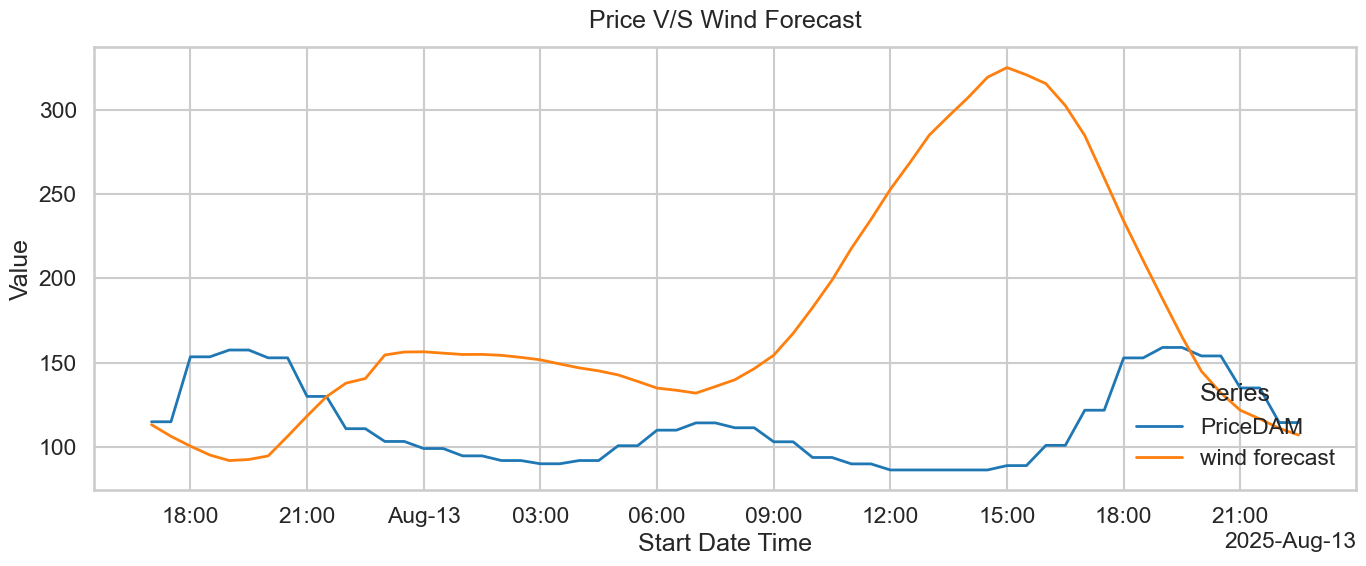

In [31]:
# EDA Done for all the Engineered features to check the trends in non-linear patterns and finalize the ones which are impactful
# Exploratory Data analysis 1 : Wind Forecast
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.dates import AutoDateLocator, ConciseDateFormatter

## Select a date range
# Define the start date
startDate = datetime.date(2025,8, 12)
startDateTime = str(startDate) + ' 17:00:00'
start = pd.to_datetime(startDateTime, format='%Y-%m-%d %H:%M:%S')

# Define the end date
endDate = datetime.date(2025, 8, 13)
endDateTime = str(endDate) + ' 22:30:00'
end = pd.to_datetime(endDateTime, format='%Y-%m-%d %H:%M:%S')

marketData['StartDateTime'] = pd.to_datetime(marketData['StartDateTime'], format='%Y-%m-%d %H:%M:%S',  errors='coerce')
df_Plot = marketData[(marketData['StartDateTime'] <= end) & (marketData['StartDateTime'] >= start)]
df_Plot = df_Plot.sort_values('StartDateTime')

df_Plot = df_Plot.dropna(subset=['IE_GB_MW', 'GB_IE_MW'], how='all') # , 'PriceIDA2', 'PriceIDA3', 'PriceImbalance'
df_Plot['PlantOutages'] = df_Plot['GU_400270']+ df_Plot['GU_400271']+ df_Plot['GU_400272']+ df_Plot['GU_400324']+ df_Plot['GU_400325']+ df_Plot['GU_400480']+ df_Plot['GU_400500']+ df_Plot['GU_400530']+ df_Plot['GU_400540']+ df_Plot['GU_400762']+ df_Plot['GU_400781']+ df_Plot['GU_400850']+ df_Plot['GU_400930']+ df_Plot['GU_401860']+ df_Plot['GU_500040']
df_Plot['wind forecast'] = (df_Plot['EmSys_C_ISEMWIND_DAM'] + df_Plot['EirGridWindFc_DAM'] + df_Plot['Meteo_ISEMWIND_DAM'] + df_Plot['ISEMWINDP90_DAM'])/8
df_Plot['AggregatedForecaststand'] = np.sqrt(df_Plot['AggregatedForecast'])

# Melt to long format for seaborn
df_long = df_Plot.melt(
    id_vars='StartDateTime',
    value_vars=['PriceDAM', 'wind forecast'], 
    var_name='Series',
    value_name='Value'
)

# Plot
sns.set(style='whitegrid', context='talk')
plt.figure(figsize=(14, 6))

ax = sns.lineplot(
    data=df_long,
    x='StartDateTime',
    y='Value',
    hue='Series',
    linewidth=2,
    palette=['#1f77b4', '#ff7f0e'])

# Title and labels
ax.set_title('Price V/S Wind Forecast', pad=14)
ax.set_xlabel('Start Date Time')

# Improve date formatting on the x-axis
locator = AutoDateLocator()
formatter = ConciseDateFormatter(locator)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)

# Legend formatting
ax.legend(title='Series', frameon=False,loc='lower right')

plt.tight_layout()
plt.show()

# OBSERVATION:
# There is a negative non-linear relationship between wind and price. 
# more wind -> more electricity generation -> -> demand met -> less price

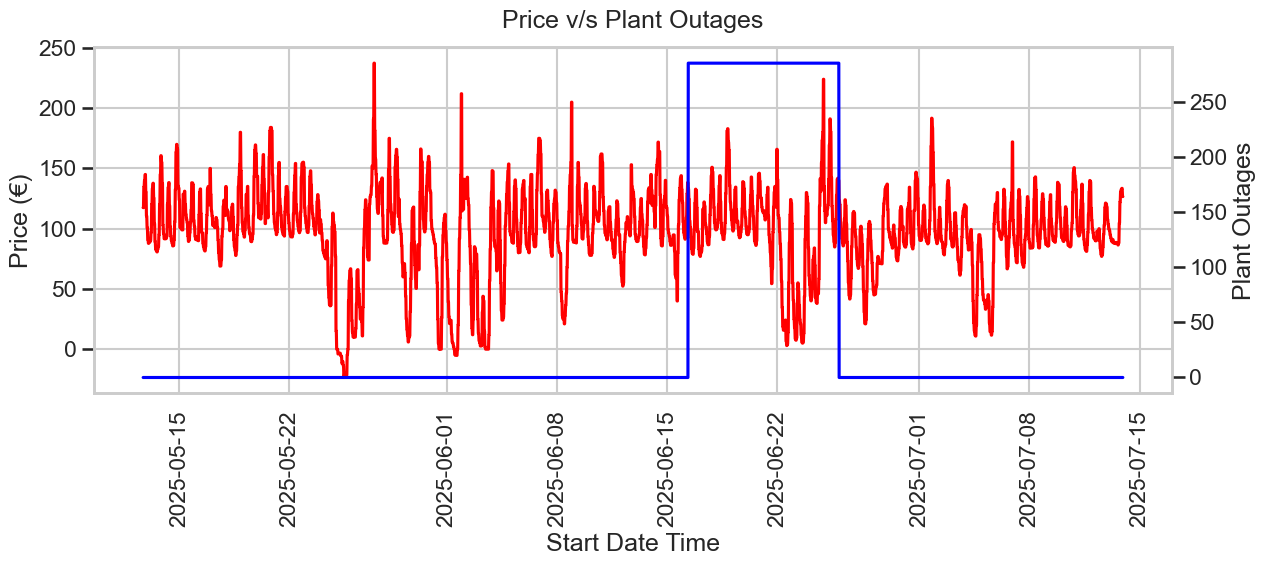

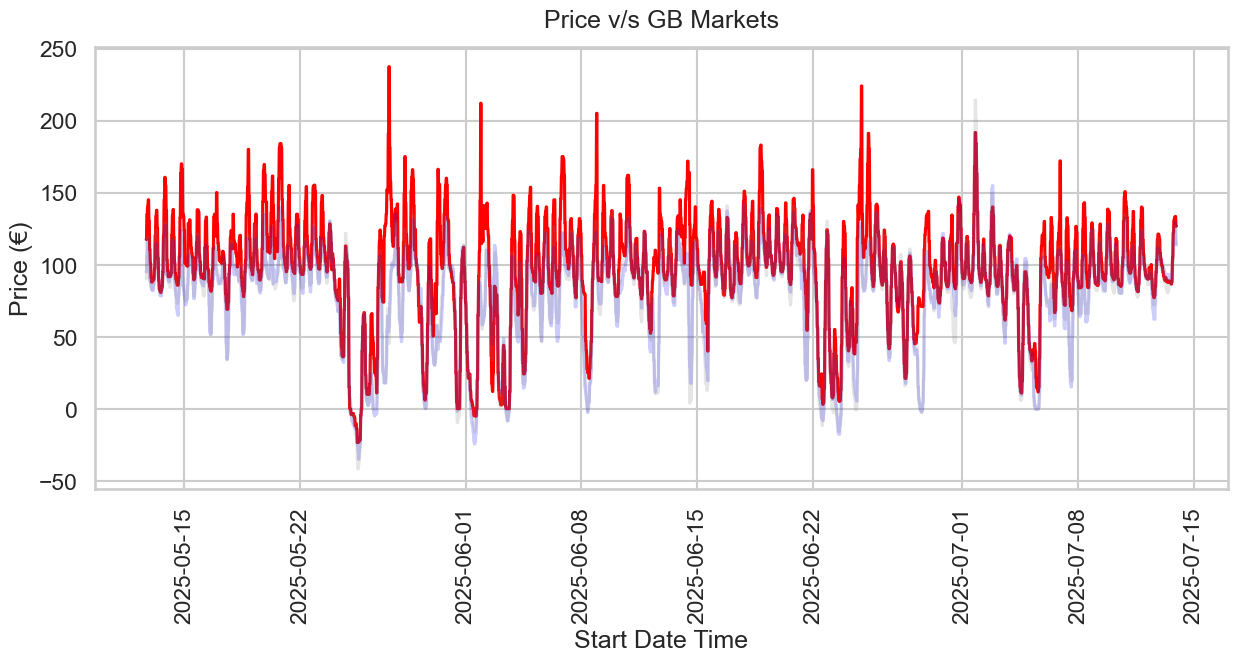

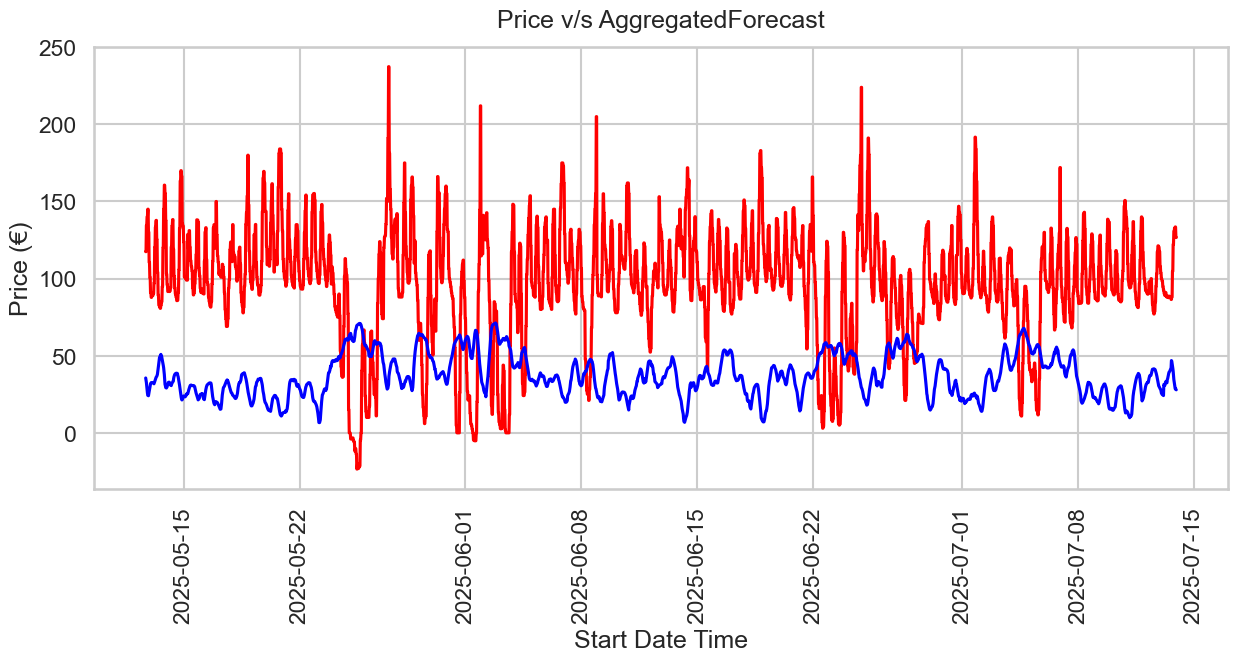

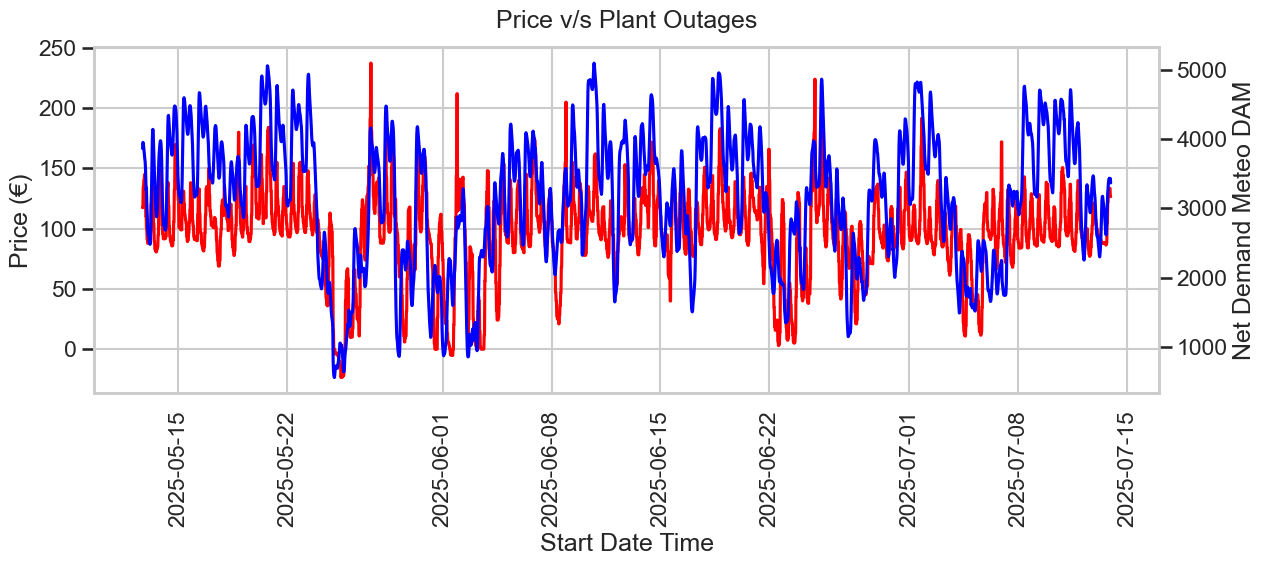

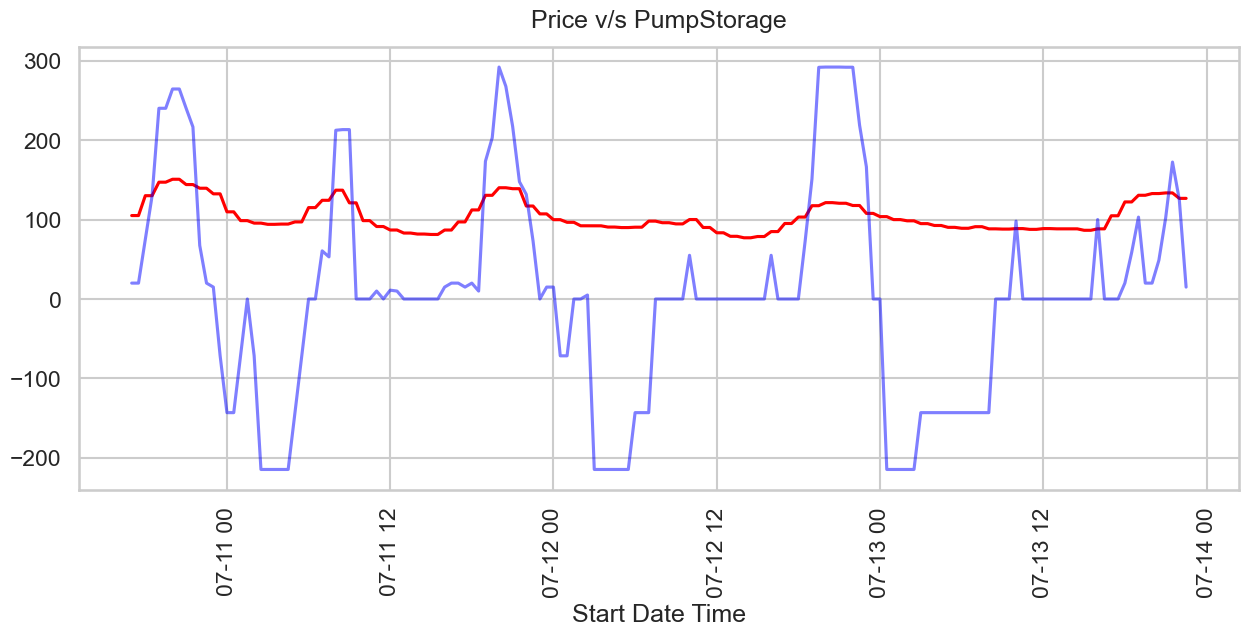

In [32]:
#Exploratory Data analysis 2 : Plant Outages

# Define the start date
startDate = datetime.date(2025,5, 12)
startDateTime = str(startDate) + ' 17:00:00'
start = pd.to_datetime(startDateTime, format='%Y-%m-%d %H:%M:%S')

# Define the end date
endDate = datetime.date(2025, 7, 13)
endDateTime = str(endDate) + ' 22:30:00'
end = pd.to_datetime(endDateTime, format='%Y-%m-%d %H:%M:%S')

marketData['StartDateTime'] = pd.to_datetime(marketData['StartDateTime'], format='%Y-%m-%d %H:%M:%S',  errors='coerce')
df_Plot = marketData[(marketData['StartDateTime'] <= end) & (marketData['StartDateTime'] >= start)]
# Sort by time (important for line charts)
df_Plot = df_Plot.sort_values('StartDateTime')


fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(df_Plot['StartDateTime'], df_Plot['PriceDAM'],color='red')
ax.set_title('Price v/s Plant Outages', pad=14)
ax.set_xlabel('Start Date Time')
ax.set_ylabel('Price (€)')
ax2= ax.twinx()
ax2.plot(df_Plot['StartDateTime'], df_Plot['GU_400271'], color='blue')
ax2.set_ylabel('Plant Outages')
ax.tick_params(axis='x', labelrotation=90)
plt.tight_layout()
plt.grid(False)
plt.show()

# OBSERVATION:
# There is a positive non-linear relationship between plant outages and price. 
# more outage -> less electricity generation -> demand not met -> more price

# Exploratory Data analysis 3 : GB_DAM_Epex, GB_DAM_N2EX

# Define the start date
startDate = datetime.date(2025,5, 12)
startDateTime = str(startDate) + ' 17:00:00'
start = pd.to_datetime(startDateTime, format='%Y-%m-%d %H:%M:%S')

# Define the end date
endDate = datetime.date(2025, 7, 13)
endDateTime = str(endDate) + ' 22:30:00'
end = pd.to_datetime(endDateTime, format='%Y-%m-%d %H:%M:%S')

marketData['StartDateTime'] = pd.to_datetime(marketData['StartDateTime'], format='%Y-%m-%d %H:%M:%S',  errors='coerce')
df_Plot = marketData[(marketData['StartDateTime'] <= end) & (marketData['StartDateTime'] >= start)]
# Sort by time (important for line charts)
df_Plot = df_Plot.sort_values('StartDateTime')


fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(df_Plot['StartDateTime'], df_Plot['PriceDAM'],color='red')
ax.set_title('Price v/s GB Markets', pad=14)
ax.set_xlabel('Start Date Time')
ax.set_ylabel('Price (€)')
ax.plot(df_Plot['StartDateTime'], df_Plot['GB_DAM_Epex'], color='blue', alpha=0.2)
ax.plot(df_Plot['StartDateTime'], df_Plot['GB_DAM_N2EX'], color='grey', alpha=0.2)
plt.tight_layout()
plt.xticks(rotation=90)
plt.show()

# OBSERVATION:
# There is a positive non-linear relationship between GB Markets and price. 
# More prices in international markets means more prices in DAM

#Exploratory Data analysis 4 :AggregatedForecast

# Define the start date
startDate = datetime.date(2025,5, 12)
startDateTime = str(startDate) + ' 17:00:00'
start = pd.to_datetime(startDateTime, format='%Y-%m-%d %H:%M:%S')

# Define the end date
endDate = datetime.date(2025, 7, 13)
endDateTime = str(endDate) + ' 22:30:00'
end = pd.to_datetime(endDateTime, format='%Y-%m-%d %H:%M:%S')

marketData['StartDateTime'] = pd.to_datetime(marketData['StartDateTime'], format='%Y-%m-%d %H:%M:%S',  errors='coerce')
df_Plot = marketData[(marketData['StartDateTime'] <= end) & (marketData['StartDateTime'] >= start)]
# Sort by time (important for line charts)
df_Plot = df_Plot.sort_values('StartDateTime')
df_Plot['AggregatedForecaststand'] = np.sqrt(df_Plot['AggregatedForecast'])

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(df_Plot['StartDateTime'], df_Plot['PriceDAM'],color='red')
ax.set_title('Price v/s AggregatedForecast', pad=14)
ax.set_xlabel('Start Date Time')
ax.set_ylabel('Price (€)')
ax.plot(df_Plot['StartDateTime'], df_Plot['AggregatedForecaststand'], color='blue')
plt.tight_layout()
plt.xticks(rotation=90)
plt.show()

# OBSERVATION:
# There is a positive non-linear relationship between AggregatedForecast and price. 
# more demand not met -> more price

#Exploratory Data analysis 5 : NetDemand_Meteo_DAM

df_Plot['NetDemand_Meteo_DAM'] = marketData['NetDemand_Meteo_DAM']
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(df_Plot['StartDateTime'], df_Plot['PriceDAM'],color='red')
ax.set_title('Price v/s Plant Outages', pad=14)
ax.set_xlabel('Start Date Time')
ax.set_ylabel('Price (€)')
ax2= ax.twinx()
ax2.plot(df_Plot['StartDateTime'], df_Plot['NetDemand_Meteo_DAM'], color='blue')
ax2.set_ylabel('Net Demand Meteo DAM')
ax.tick_params(axis='x', labelrotation=90)
plt.tight_layout()
plt.grid(False)
plt.show()

# OBSERVATION:
# There is a positive non-linear relationship between NetDemand_Meteo_DAM and price. 
# more demand not met -> more price(most of the demand is compensated by wind generation, so the wind is subtracted from the demand forecast
# to get better variable relationship)

# Exploratory Data analysis 6 : PumpStorage

startDate = datetime.date(2025,7, 10)
startDateTime = str(startDate) + ' 17:00:00'
start = pd.to_datetime(startDateTime, format='%Y-%m-%d %H:%M:%S')
endDate = datetime.date(2025, 7, 13)
endDateTime = str(endDate) + ' 22:30:00'
end = pd.to_datetime(endDateTime, format='%Y-%m-%d %H:%M:%S')

marketData['StartDateTime'] = pd.to_datetime(marketData['StartDateTime'], format='%Y-%m-%d %H:%M:%S',  errors='coerce')
df_Plot = marketData[(marketData['StartDateTime'] <= end) & (marketData['StartDateTime'] >= start)]
# Sort by time (important for line charts)
df_Plot = df_Plot.sort_values('StartDateTime')

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(df_Plot['StartDateTime'], df_Plot['PriceDAM'],color='red')
ax.set_title('Price v/s PumpStorage', pad=14)
ax.set_xlabel('Start Date Time')
ax.plot(df_Plot['StartDateTime'], df_Plot['PumpStorage'], color='blue', alpha= 0.5)
plt.tight_layout()
plt.xticks(rotation=90)
plt.show()

# OBSERVATION:
# There is a positive non-linear relationship between NetDemand_Meteo_DAM and price. 
# More pump Storage -> more price


In [33]:
# Aditi
# List of selected features for model
Features_selected = ['NetDemand_Meteo_DAM',
'NetDemand_EG_DAM',
'NetDemand_ISEM_DAM',
'Wind_Forecast_Average',
'LoadForecastROI',
'LoadForecastNI',
'AggregatedForecast',
'EmSys_C_ISEMWIND_DAM',
'ISEMWINDP10_DAM',
'Plant_Outage_Sum',
'GB_DAM_Epex',
'GB_DAM_N2EX',
'GB_DAM_HH_Epex',
'PumpStorage',
'LTS_IC_ROI',
'LTS_IC_NI']
Target_var = 'Spread_DAM_to_IDA1'


model_df = marketData[["StartDateTime"] + Features_selected + ["Spread_DAM_to_IDA1"]].copy()

model_df = model_df.dropna(subset=Features_selected + ["Spread_DAM_to_IDA1"])
model_df = model_df.sort_values("StartDateTime")
model_df['direction_label'] = np.where(model_df[Target_var] > 0, 1, -1)

In [34]:
#Experimental columns to enhance model performance
model_df['day'] = marketData['StartDateTime'].dt.day
model_df['year'] = marketData['StartDateTime'].dt.year
model_df['month'] = marketData['StartDateTime'].dt.month

In [35]:
#Experimental columns to enhance model performance
model_df['day'] = marketData['StartDateTime'].dt.day
model_df['year'] = marketData['StartDateTime'].dt.year
model_df['month'] = marketData['StartDateTime'].dt.month


model_df['price_vol_24h'] = marketData['PriceDAM'].shift(1)  #.rolling(24, min_periods=12).std()


# Time features (cyclical)
model_df['hour_sin'] = np.sin(2 * np.pi * marketData['StartDateTime'].dt.hour / 24)
model_df['weekday'] = marketData['StartDateTime'].dt.weekday

drop_cols = ["StartDateTime", Target_var, "direction_label"]
x_model = model_df.drop(columns=drop_cols)
y_model = model_df["direction_label"]
model_dt = model_df["StartDateTime"]


In [36]:
#Aditi
# Separating Features columns and label columns for further processing
# The percentage split was optimized bby running the model for splits with 5% difference.
n = len(model_df)
train_end = int(n * 0.6)
val_end = int(n * 0.8)
x_train, x_val_test = x_model.iloc[:train_end], x_model.iloc[train_end:]
y_train, y_val_test = y_model.iloc[:train_end], y_model.iloc[train_end:]

x_val, x_test  = x_model.iloc[train_end:val_end], x_model.iloc[val_end:]
y_val, y_test = y_model.iloc[train_end:val_end], y_model.iloc[val_end:]

display(x_train.shape)
display(y_train.shape)

display(x_test.shape)
display(y_test.shape)

display(x_val.shape)
display(y_val.shape)

(30516, 22)

(30516,)

(10173, 22)

(10173,)

(10172, 22)

(10172,)

In [37]:
#Aditi
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression

# Creating both classifiers with optimized parameters, the parameter values were optimized by tuning them with training data and 
# analysing the result based on the accuracy obtained.

rf = RandomForestClassifier(n_estimators=251, max_depth=None, min_samples_split=9, min_samples_leaf=4, random_state=42, n_jobs=-1)
cb = CatBoostClassifier(iterations=814, depth=6, learning_rate=0.051, l2_leaf_reg=7.798757767167708,
                       random_state=42, verbose=0)  


ensemble = StackingClassifier(
    estimators=[
        ('rf', rf),      
        ('cb', cb),      
    ],
    final_estimator=LogisticRegression(random_state=42),
    cv=3, stack_method='predict_proba', n_jobs=-1
)

print("Training ensemble...")
ensemble.fit(x_train, y_train)
y_pred_proba_ensemble = ensemble.predict_proba(x_test)[:, 1]

print("Ensemble shapes:", y_pred_proba_ensemble.shape)
print("Ensemble test AUC:", f"{roc_auc_score(y_test, y_pred_proba_ensemble):.3f}")

Training ensemble...
Ensemble shapes: (10173,)
Ensemble test AUC: 0.722


In [38]:
#Aditi

# Threshold Optimization for best trading results. 
# This part of code decides when to trade to maximize profit
emwh_list={}
prev_metric_eur_per_mwh=0
for threshold_high in np.arange(0.55, 0.75, 0.02):     
    for threshold_low in np.arange(0.25, 0.45, 0.02): 
        # Trade mask explianing that we trade when the predict confidence is greter than threshold_high and lower than threshold_low
        trade_mask = (y_pred_proba_ensemble >= threshold_high) | (y_pred_proba_ensemble <= threshold_low)
        y_pred_sign = np.where(y_pred_proba_ensemble >= threshold_high, 1, -1)
        y_pred_sign[~trade_mask] = 0
        
        spread_test = model_df[Target_var].iloc[val_end:].values
        volume_test = np.ones_like(spread_test)
        # Checking correctness of prediction, if the direction match we trade.        
        pl = np.where(np.sign(spread_test) == y_pred_sign, 
                      np.abs(spread_test), 
                      -np.abs(spread_test))
        pl[~trade_mask] = 0
        total_pl = pl.sum() 
        total_volume_traded = volume_test[trade_mask].sum()
        metric_eur_per_mwh = total_pl / total_volume_traded if total_volume_traded > 0 else 0
        # Displaying only optimal outputs
        if metric_eur_per_mwh > 13.19 and trade_mask.mean()>0.35:
            ensemble_auc = roc_auc_score(y_test, y_pred_proba_ensemble)
            if metric_eur_per_mwh > prev_metric_eur_per_mwh:
                emwh_list['threshold_low'] = threshold_low
                emwh_list['threshold_high'] = threshold_high
                emwh_list['ensemble_auc'] = ensemble_auc
                emwh_list['metric_eur_per_mwh'] = metric_eur_per_mwh
                emwh_list['tm'] = trade_mask
                emwh_list['pl'] = pl
                emwh_list['total_pl'] = total_pl
                emwh_list['y_pred_sign'] = y_pred_sign
            print(f"Threshold: {threshold_low}-{threshold_high}")
            print(f"Ensemble AUC: {ensemble_auc:.3f}")
            print(f"Ensemble €/MWh: {metric_eur_per_mwh:.2f}")
            print(f"Ensemble trades: {trade_mask.sum()}/{len(trade_mask)} ({trade_mask.mean():.1%})\n")
            prev_metric_eur_per_mwh = metric_eur_per_mwh
print(emwh_list)

Threshold: 0.27-0.5900000000000001
Ensemble AUC: 0.722
Ensemble €/MWh: 13.26
Ensemble trades: 3568/10173 (35.1%)

Threshold: 0.29000000000000004-0.5900000000000001
Ensemble AUC: 0.722
Ensemble €/MWh: 13.34
Ensemble trades: 3658/10173 (36.0%)

Threshold: 0.31000000000000005-0.5900000000000001
Ensemble AUC: 0.722
Ensemble €/MWh: 13.20
Ensemble trades: 3820/10173 (37.6%)

{'threshold_low': np.float64(0.29000000000000004), 'threshold_high': np.float64(0.5900000000000001), 'ensemble_auc': 0.721804850376279, 'metric_eur_per_mwh': np.float64(13.340773646801532), 'tm': array([False, False, False, ...,  True,  True,  True], shape=(10173,)), 'pl': array([0.  , 0.  , 0.  , ..., 1.02, 5.23, 5.23], shape=(10173,)), 'total_pl': np.float64(48800.55), 'y_pred_sign': array([0, 0, 0, ..., 1, 1, 1], shape=(10173,))}


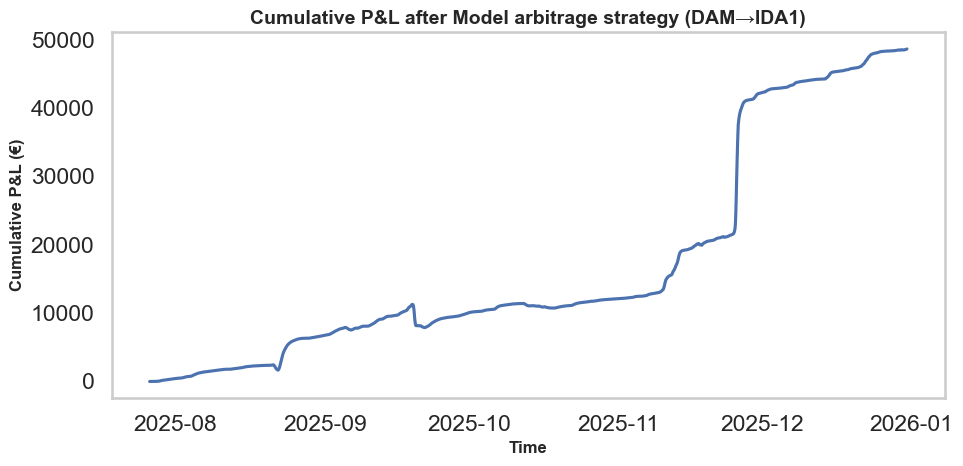

In [39]:
#Aditi
alpha = 0.03
pnl_smooth_ema = pd.Series(emwh_list['pl']).ewm(alpha=alpha, adjust=False).mean().values
cum_pl_smooth_ema = np.cumsum(pnl_smooth_ema)

time_test = model_df['StartDateTime'].iloc[val_end:].values 

plt.figure(figsize=(10, 5))
plt.plot(time_test, cum_pl_smooth_ema)
plt.xlabel("Time", fontweight="bold", fontsize=12 )
plt.ylabel("Cumulative P&L (€)", fontweight="bold", fontsize=12)
plt.title("Cumulative P&L after Model arbitrage strategy (DAM→IDA1)", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.grid()
plt.show()

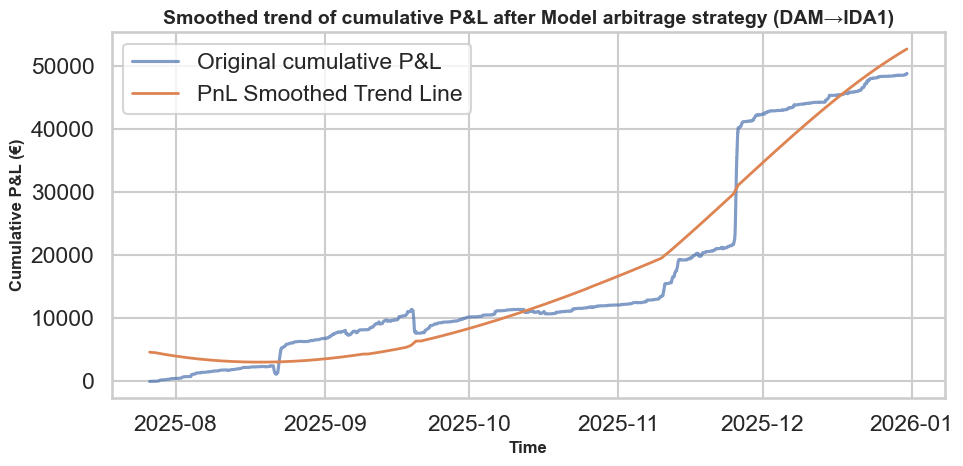

In [40]:
#Aditi

cum_pl = np.cumsum(emwh_list['pl'])
x = np.arange(len(cum_pl))

deg = 3  
coeffs = np.polyfit(x, cum_pl, deg)
cum_pl_trend = np.polyval(coeffs, x)

time_test = model_df['StartDateTime'].iloc[val_end:].values  # or use range(len(cum_pl))

plt.figure(figsize=(10, 5))
plt.plot(time_test, cum_pl, alpha=0.7, label="Original cumulative P&L")
plt.plot(time_test, cum_pl_trend, label=f"PnL Smoothed Trend Line", linewidth=2)
plt.xlabel("Time", fontweight="bold", fontsize=12 )
plt.ylabel("Cumulative P&L (€)", fontweight="bold", fontsize=12)
plt.title("Smoothed trend of cumulative P&L after Model arbitrage strategy (DAM→IDA1)", fontweight="bold", fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig("Cumulative_Profit_and_Loss.png")
plt.show()


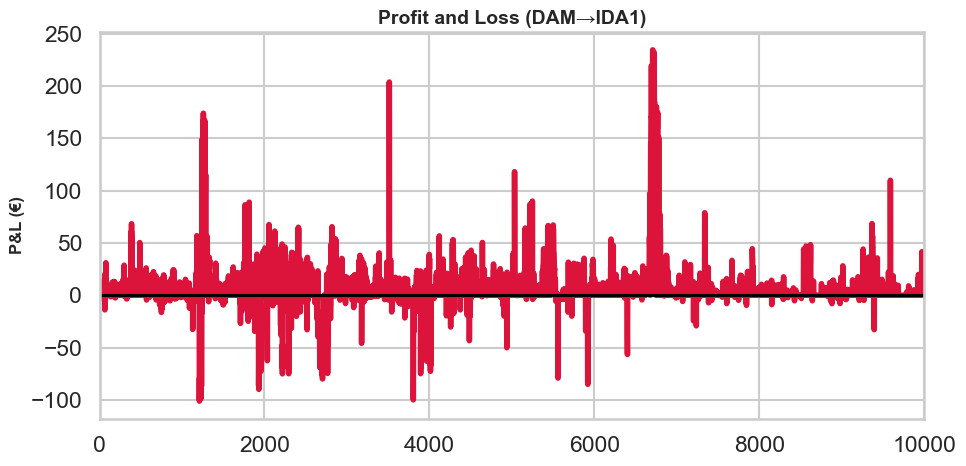

In [41]:
#Aditi
time_test = model_df['StartDateTime'].iloc[val_end:]
plt.figure(figsize=(10, 5))
plt.plot(emwh_list['pl'], linewidth=4, color='crimson')
plt.axhline(0, color='black')
plt.xlim(0,10000)
plt.ylabel("P&L (€)", fontweight="bold", fontsize=12)
plt.title("Profit and Loss (DAM→IDA1)", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.savefig("Profit_and_Loss.png")
plt.show()


In [ ]:
#Aditi
directions= emwh_list['y_pred_sign']
import numpy as np
import matplotlib.pyplot as plt

# Create directional bar plot
fig, ax = plt.subplots(figsize=(12, 3))

x = np.arange(len(directions))
colors = ['green' if d == 1 else 'red' if d == -1 else 'lightgray' for d in directions]
bars = ax.bar(x, directions, color=colors, width=1, alpha=0.7, edgecolor='black', linewidth=0.5)

# Zero line
ax.axhline(0, color='black', linewidth=1)
ax.set_ylim(-1.2, 1.2)
ax.set_xlim(1970, 2118)
ax.set_xlabel('Time Periods', fontweight="bold", fontsize=12)
ax.set_ylabel('Direction', fontweight="bold", fontsize=12)
ax.set_title('Directional Trading Signals', fontweight="bold", fontsize=12)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("Directional_Trading_Signals.png")
plt.show()

